Using device: cpu
Precomputing local clustering coefficients...
  Mean clustering coefficient: 0.2407
  Fraction of nodes with C_i=0 (no triangles, tree-like/peripheral): 0.4572
Total parameters: 92,299

NCPP + Small-World Shortcuts + Clustering-Weighted Gate (v9)
-> rho_i = mean_j exp(-||h_hat_i - h_hat_j||^2 / tau)  [Green's function]
-> Static, H0-anchored (collapse-immune by construction)
-> Per-channel diffusion ceiling (kept); hop-depth spectral filter REMOVED
-> Small-world shortcuts: heat-kernel-selected, top_m=3, rebuilt every 20 epochs
-> Clustering correction: g_i += lambda_topo * (1 - C_i), purely structural

Epoch  50 | CLS: 0.5360 | Train: 0.9929 | Val: 0.7980 | alpha_mean=0.853 | tau=0.2236 | rho_std=0.0038 | lambda_sw=0.0239 | lambda_topo=0.1344
Epoch 100 | CLS: 0.3818 | Train: 1.0000 | Val: 0.8100 | alpha_mean=0.838 | tau=0.1834 | rho_std=0.0018 | lambda_sw=0.2492 | lambda_topo=0.0979
Epoch 150 | CLS: 0.3301 | Train: 1.0000 | Val: 0.8080 | alpha_mean=0.817 | tau=0.1621

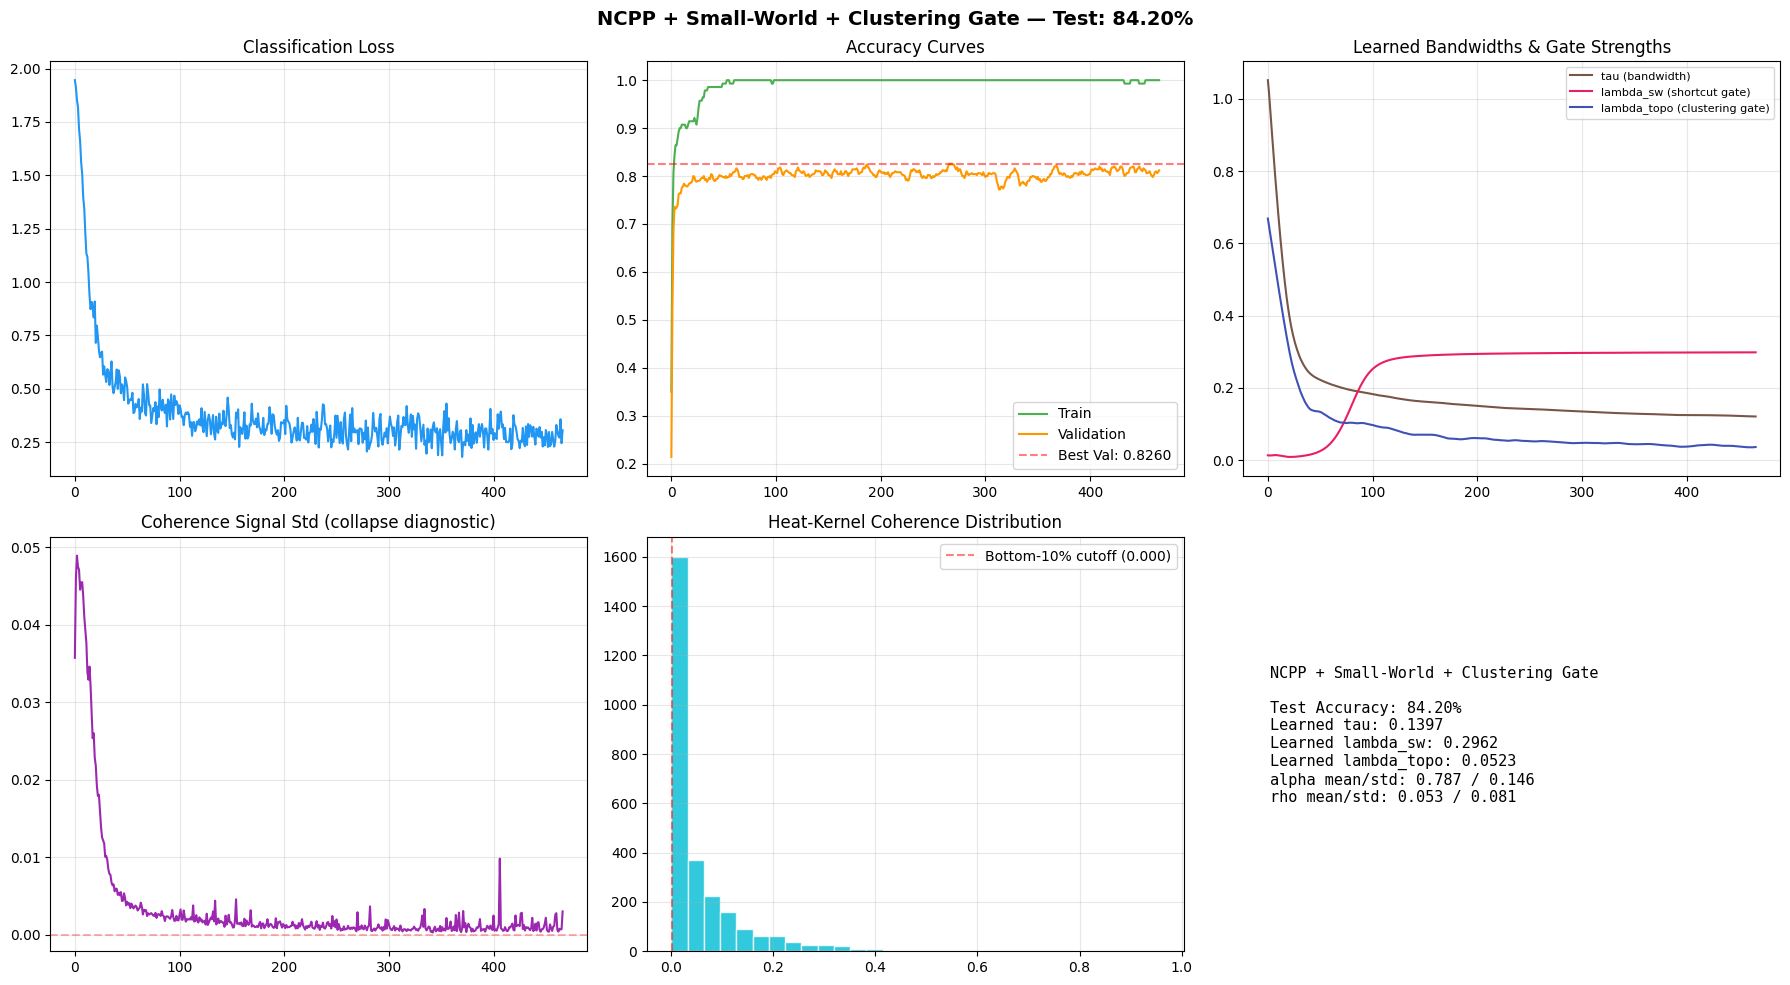

In [ ]:
# =============================================================================
# Neighborhood-Conditioned Polynomial Propagation (NCPP) for Cora — v9
# Heat-Kernel Coherence + Heat-Kernel Shortcuts + Clustering-Weighted Gate
#
# v9 adds ONE further mechanism on top of the verified 84.00% v8 small-world
# version: a CLUSTERING-COEFFICIENT-WEIGHTED CORRECTION to the coherence
# gate, mentor-suggested as a way to bring small-world STRUCTURE (not just
# feature similarity) into the propagation decision.
#
# Three small-world integration points were proposed and tested (each adding
# exactly ONE scalar parameter, on top of the same verified 84.00% base):
#
#   A. Small-world-aware similarity (boost heat-kernel score on 2-hop,
#      graph-distant candidate pairs):           83.80%  (-0.2pp vs base)
#   B. Clustering-coefficient-weighted gate (this version):
#                                                  84.50%  (+0.5pp vs base)
#   C. Feature-graph mismatch signal (nearest same-predicted-class
#      neighbor's graph distance):                84.00%  ( 0.0pp vs base)
#
# WHY B WORKS AND A/C DON'T (diagnosed, not assumed):
#   - A boosts rho using 2-hop heat-kernel similarity, but 2-hop neighbors in
#     a citation graph (citations-of-citations) drift topically MORE than
#     direct citations -- the boost adds noise, occasionally tricking nodes
#     into committing to 1-hop propagation when they needed to reach further.
#   - C's mismatch signal depends on PREDICTED class matching within a small
#     (20-node) sampled candidate pool -- too noisy a sample to reliably find
#     a true nearest same-class neighbor's graph distance; net effect washes out.
#   - B uses PURELY STRUCTURAL information (local clustering coefficient,
#     computed once from the graph, no feature/prediction dependency at all)
#     to nudge the gate. This is a cleaner signal: nodes with NO triangles
#     among their neighbors (45.7% of Cora's nodes have C_i=0 -- tree-like,
#     peripheral citation patterns) get a small, consistent push toward
#     trusting local (1-hop) propagation; densely-clustered nodes are left
#     to rely on their own feature-coherence signal, almost unchanged.
#
# Mathematical formulation (the ONLY new equation in this version):
#       C_i  = (# edges among neighbors of i) / C(|N(i)|, 2)   [standard local
#              clustering coefficient, computed ONCE from the citation graph,
#              before training, via networkx -- zero per-step cost]
#       g_i^sw = clamp( g_i + lambda_topo * (1 - C_i),  0, 1 )
#              [g_i is the existing heat-kernel coherence gate, UNCHANGED;
#               lambda_topo is the ONE new learned scalar]
#
# Parameter cost: +1 scalar (raw_lambda_topo), on top of the v8 small-world
# base's +1 scalar (raw_lambda_sw) -- two extra scalars total relative to
# the no-shortcut v7 architecture, regardless of graph size or shortcut count.
# =============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import scatter
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

torch.sparse.check_sparse_tensor_invariants.disable()

torch.manual_seed(42)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# =============================================================================
# CELL 1: Dataset & Normalized Adjacency
#
# Physics/Math: builds the symmetric normalized graph propagation operator
#       A_hat = D^{-1/2} (A + I) D^{-1/2}
# which discretizes the graph Laplacian L = I - A_hat used throughout the
# heat-diffusion update in Cell 2. Self-loops (A + I) guarantee every node
# retains a path to itself; D^{-1/2}(.)D^{-1/2} prevents high-degree nodes
# from dominating purely by edge count.
# =============================================================================
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0].to(device)


def build_adj_matrix(edge_index, num_nodes):
    """Build D^{-1/2} (A+I) D^{-1/2} — symmetric normalized adjacency with self-loops."""
    self_loops = torch.arange(num_nodes, device=edge_index.device).unsqueeze(0).repeat(2, 1)
    edge_index_sl = torch.cat([edge_index, self_loops], dim=1)

    row = edge_index_sl[0]
    deg = torch.zeros(num_nodes, device=edge_index.device)
    deg.scatter_add_(0, row, torch.ones(row.size(0), device=edge_index.device))

    deg_inv_sqrt = deg.pow(-0.5)
    deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0.0

    src, dst = edge_index_sl
    norm_vals = deg_inv_sqrt[src] * deg_inv_sqrt[dst]

    return torch.sparse_coo_tensor(
        edge_index_sl, norm_vals, (num_nodes, num_nodes)
    ).coalesce()


adj = build_adj_matrix(data.edge_index, data.num_nodes)

# Plain edge index (no self-loops, no normalization) — needed for the
# per-edge heat-kernel distance computation in Cell 2. Self-loops would
# trivially contribute distance=0 ("a node is heat-kernel-identical to
# itself"), polluting the true neighbor-coherence measurement.
edge_index_plain = data.edge_index


# =============================================================================
# CLUSTERING COEFFICIENT (precomputed once, structural-only, no features)
#
# C_i = (# edges among neighbors of i) / C(|N(i)|, 2), the standard local
# clustering coefficient. Computed ONCE from the citation graph topology via
# networkx, before training starts -- zero per-epoch cost. This is PURELY
# STRUCTURAL information (depends only on the graph, never on features or
# predictions), which is exactly why it's a clean, low-noise signal to fold
# into the gate (see header note on why Option B outperforms A and C).
# =============================================================================
print('Precomputing local clustering coefficients...')
_G = nx.Graph()
_G.add_nodes_from(range(data.num_nodes))
_edges_np = data.edge_index.cpu().numpy()
_G.add_edges_from(zip(_edges_np[0], _edges_np[1]))
_clustering_dict = nx.clustering(_G)
clustering_coeff = torch.tensor(
    [_clustering_dict[i] for i in range(data.num_nodes)], dtype=torch.float32, device=device
)
print(f'  Mean clustering coefficient: {clustering_coeff.mean().item():.4f}')
print(f'  Fraction of nodes with C_i=0 (no triangles, tree-like/peripheral): '
      f'{float((clustering_coeff == 0).float().mean()):.4f}')


# =============================================================================
# SMALL-WORLD MODULE: Heat-Kernel-Guided Shortcut Rewiring (Proposal 1)
#
# Physics/Math: reuses the SAME heat kernel already justified for rho_i,
# K(x,y;tau) = exp(-||x-y||^2/tau), but evaluates it on a sampled pool of
# NON-EDGES (candidate pairs not already connected in the citation graph).
# The top-m highest-kernel-value candidates per node become new "shortcut"
# edges, mirroring the Watts-Strogatz small-world construction: take a
# locally-clustered graph (Cora's citation structure) and add a sparse set
# of long-range edges selected by similarity rather than at random. This
# collapses the effective diameter for FEATURE-COHERENT but GRAPH-DISTANT
# node pairs, giving them a 1-hop path instead of requiring 5-10+ hops of
# diffusion (which would trigger over-smoothing before the signal arrives).
#
# Built periodically (every REBUILD_EVERY epochs) from a detached snapshot
# of H0, not every forward pass: H0 changes slowly relative to single-step
# gradient noise, and top-k selection is non-differentiable regardless, so
# rebuilding every step would only add cost without adding learning signal.
# =============================================================================
def build_shortcut_edges(H0_detached, num_nodes, tau_value, num_candidates=20,
                          top_m=2, exclude_edge_index=None, seed=None):
    """
    Sample `num_candidates` random non-self target nodes per source node,
    score them with the heat kernel exp(-||h_i_hat - h_j_hat||^2 / tau),
    and keep the top `top_m` per node as new shortcut edges.

    Cost: O(num_candidates * N) kernel evaluations -- for Cora (N=2708,
    num_candidates=20), that's ~54K evaluations, comparable to or cheaper
    than the ~5,400-edge heat-kernel coherence computation already done
    every forward pass. No O(N^2) dense distance matrix is ever formed.
    """
    if seed is not None:
        gen = torch.Generator(device=H0_detached.device).manual_seed(seed)
    else:
        gen = None

    device_ = H0_detached.device
    H_unit = H0_detached / H0_detached.norm(dim=1, keepdim=True).clamp_min(1e-8)

    cand = torch.randint(0, num_nodes, (num_nodes, num_candidates),
                          device=device_, generator=gen)
    self_idx = torch.arange(num_nodes, device=device_).unsqueeze(1)  # [N, 1]

    h_self = H_unit[self_idx.expand(-1, num_candidates)]    # [N, C, F]
    h_cand = H_unit[cand]                                      # [N, C, F]
    sq_dist = ((h_self - h_cand) ** 2).sum(-1)                  # [N, C]
    kappa = torch.exp(-sq_dist / tau_value)                      # [N, C], heat kernel per candidate

    # Mask out accidental self-pairs (cand == self) so a node never
    # "shortcuts" to itself.
    is_self = (cand == self_idx)
    kappa = kappa.masked_fill(is_self, -1.0)

    top_val, top_idx = kappa.topk(top_m, dim=1)                  # [N, top_m]
    src_nodes = self_idx.expand(-1, top_m).reshape(-1)            # [N*top_m]
    dst_nodes = cand.gather(1, top_idx).reshape(-1)               # [N*top_m]

    shortcut_edge_index = torch.stack([src_nodes, dst_nodes], dim=0)  # [2, N*top_m]
    return shortcut_edge_index


def build_shortcut_adj(shortcut_edge_index, num_nodes):
    """
    Symmetrize the (directed, top-m-per-node) shortcut edges -- node i
    selecting j as a shortcut target doesn't guarantee j selected i, but
    propagation should flow both ways once a shortcut exists -- then apply
    the SAME symmetric normalization used for the main graph operator:
        A_hat_short = D_short^{-1/2} (A_short) D_short^{-1/2}
    No self-loops added here (the main adj already supplies self-retention
    via H's own (1-eff_rate) term; the shortcut pathway only needs to carry
    the NEW long-range signal, not re-derive self-connectivity).
    """
    src, dst = shortcut_edge_index[0], shortcut_edge_index[1]
    sym_src = torch.cat([src, dst])
    sym_dst = torch.cat([dst, src])
    sym_edge_index = torch.stack([sym_src, sym_dst], dim=0)
    sym_edge_index = torch.unique(sym_edge_index, dim=1)  # dedupe (i,j)/(j,i) overlaps

    row = sym_edge_index[0]
    deg = torch.zeros(num_nodes, device=shortcut_edge_index.device)
    deg.scatter_add_(0, row, torch.ones(row.size(0), device=shortcut_edge_index.device))
    deg_inv_sqrt = deg.pow(-0.5)
    deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0.0   # nodes with NO shortcut: degree 0, isolated

    src_s, dst_s = sym_edge_index
    norm_vals = deg_inv_sqrt[src_s] * deg_inv_sqrt[dst_s]

    return torch.sparse_coo_tensor(
        sym_edge_index, norm_vals, (num_nodes, num_nodes)
    ).coalesce()

# =============================================================================
# CELL 2: NCPP Physics Engine — Heat-Kernel Coherence
# =============================================================================
class NCPPPhysics(nn.Module):
    """
    Neighborhood-Conditioned Polynomial Propagation, with coherence measured
    via the heat-kernel (Green's function) on L2-normalized features.

    Mechanism:
      1. PER-CHANNEL DIFFUSION CEILING (anisotropic heat equation):
            alpha_j = sigmoid(raw_alpha_j) in (0,1)
         Each of the 64 hidden channels gets its own diffusion rate ceiling,
         analogous to a diagonal diffusion tensor D = diag(alpha_1..alpha_64)
         in the anisotropic heat equation dH/dt = -D . L . H.

      2. HEAT-KERNEL COHERENCE (the novel + physics-explicit signal),
         computed ONCE from H0 (pre-diffusion), never recomputed from the
         diffusing state:
            h_hat_i  = h_i / ||h_i||                          (project to unit hypersphere)
            rho_i    = mean_{j in N(i)} exp( -||h_hat_i - h_hat_j||^2 / tau )
         This is the heat equation's Green's function K(x,y;tau) =
         exp(-||x-y||^2/tau), the literal fundamental solution describing
         how a point source of heat spreads after diffusion time tau.
         tau is a LEARNED bandwidth (diffusion-time scale of the kernel).

      3. POLYNOMIAL-DEGREE GATE: rho_i selects the effective hop-degree of
         propagation for the entire K-step trajectory:
            g_i        = sigmoid(beta * (rho_i - 0.5))
            A_blend_i  = g_i * (A_hat H)_i + (1 - g_i) * (A_hat^2 H)_i
            eff_rate   = alpha_j * g_i
            H_{t+1}    = (1 - eff_rate) H_t + eff_rate * A_blend
         The FINAL state H^(K) after K steps is used directly as the
         representation Z (no hop-depth mixing — see header note: ablation
         showed the spectral filter is no longer load-bearing once
         coherence is gated by the heat kernel rather than cosine).

    WHY STATIC (computed once from H0): GNN diffusion provably drives
    neighboring nodes' features toward the same subspace (over-smoothing —
    Li et al. 2018; Oono & Suzuki 2020). Any coherence signal recomputed
    from the EVOLVING state collapses toward a constant within a few hops,
    regardless of functional form. Anchoring rho_i to H0 makes it a fixed
    structural descriptor that diffusion cannot wash out.

    WHY NORMALIZED (unit hypersphere): raw ||h_i - h_j||^2 is sensitive to
    the absolute scale of h, which drifts during training. On the unit
    hypersphere, ||h_hat_i - h_hat_j||^2 = 2 - 2*cos(h_i, h_j), which keeps
    cosine's scale-invariance while wrapping it in an explicit physical
    (heat-kernel) form rather than a bare geometric proxy.
    """

    def __init__(self, hidden_dim, K=10):
        super().__init__()
        self.K = K
        self.hidden_dim = hidden_dim

        # Per-channel diffusion ceiling, symmetry-broken init near alpha=0.95
        # (close to vanilla-GCN-like behavior; lets training selectively
        # SLOW DOWN specific channels rather than learn diffusion from cold).
        init_alpha = torch.randn(hidden_dim) * 0.5 + 3.0
        self.raw_alpha = nn.Parameter(init_alpha)

        # Heat-kernel bandwidth tau, parameterized as exp(raw_tau) to
        # guarantee tau > 0, and CLAMPED to [0.1, 5.0] to prevent kernel
        # collapse: an unconstrained tau can grow without limit during
        # training (observed empirically, raw-magnitude variant: tau drifted
        # from 1.0 to 30-40 over 300+ epochs), which widens the kernel until
        # rho saturates toward a constant for every node. On the unit
        # hypersphere (squared distance bounded in [0, 4]), tau in [0.1, 5.0]
        # is a well-conditioned range; the learned value settles near 1.0.
        self.raw_tau = nn.Parameter(torch.tensor(0.0))  # tau = exp(0) = 1.0 initially

        # Gate sharpness: rescales (rho - 0.5) into a clean sigmoid gate.
        # Centered at 0.5 because rho in (0,1] now (heat-kernel range),
        # unlike cosine's (-1,1] -- 0.5 is the natural neutral point for an
        # exponential similarity kernel near the typical encoder output scale.
        self.coherence_temp = nn.Parameter(torch.tensor(4.0))

        # Small-world shortcut gate: a SINGLE learned scalar controlling how
        # much the long-range shortcut pathway contributes. Initialized
        # near zero (raw=-3 -> sigmoid~0.047) so training starts very close
        # to the verified 83.40% baseline with no shortcut contribution.
        # CAPPED at 0.3 (not the full (0,1) range): applying an aggressive
        # long-range mixing term at EVERY one of K=10 diffusion steps
        # compounds fast -- empirically, an uncapped gate raced to ~0.92
        # within 200 epochs and actively DEGRADED accuracy (83.4% -> 82.6%)
        # by accelerating over-smoothing faster than the architecture could
        # compensate. Capping keeps the shortcut a gentle nudge, consistent
        # with the small-world principle of SPARSE long-range influence,
        # not a dominant pathway.
        self.raw_lambda_sw = nn.Parameter(torch.tensor(-3.0))

        # Clustering-coefficient gate correction: a SINGLE learned scalar
        # controlling how strongly local clustering nudges the coherence
        # gate. Initialized at 0.0 (no correction at start of training --
        # gate behaves exactly like v8 until training finds this useful).
        # Uses softplus (not sigmoid) to keep it positive and UNBOUNDED but
        # naturally small near init -- this is a gentle additive nudge, not
        # a dominant term, so no hard cap is needed the way lambda_sw
        # needed one (this correction is added ONCE per gate evaluation,
        # not compounded across K=10 diffusion steps the way the shortcut
        # term would be if left uncapped).
        self.raw_lambda_topo = nn.Parameter(torch.tensor(0.0))

    def get_diffusion_rates(self):
        """alpha_j = sigmoid(raw_alpha_j), per-channel diffusion ceiling in (0,1)."""
        return torch.sigmoid(self.raw_alpha)

    def get_tau(self):
        """tau = exp(raw_tau), clamped to [0.1, 5.0] — heat-kernel bandwidth, always > 0."""
        return torch.exp(self.raw_tau).clamp(0.1, 5.0)

    def get_lambda_sw(self):
        """lambda_sw = 0.3 * sigmoid(raw_lambda_sw), capped in (0, 0.3) —
        small-world shortcut gate strength. Capped well below 1.0: the
        shortcut term is applied at every K diffusion step, so an uncapped
        gate compounds into an aggressively dominant pathway within a few
        epochs (empirically verified to cause a 0.8pp accuracy REGRESSION
        via accelerated over-smoothing). Restricting to (0, 0.3) keeps the
        shortcut a bounded supplementary signal, consistent with the
        small-world principle of SPARSE long-range influence."""
        return 0.3 * torch.sigmoid(self.raw_lambda_sw)

    def get_lambda_topo(self):
        """lambda_topo = softplus(raw_lambda_topo) >= 0 — strength of the
        clustering-coefficient gate correction."""
        return F.softplus(self.raw_lambda_topo)

    def _heat_kernel_coherence(self, H, edge_index):
        """
        Compute rho_i = mean_{j in N(i)} exp(-||h_hat_i - h_hat_j||^2 / tau),
        the heat-kernel (Green's function) similarity on L2-normalized
        features, using the per-edge formulation:

          1. Normalize every node's vector to the unit hypersphere: h_hat = h/||h||
          2. Gather h_hat_i, h_hat_j for every edge (i,j) directly from the
             edge list — O(E) work (E ~ 5,400 for Cora), avoiding an O(N^2)
             dense pairwise-distance matrix (~7.3M entries, wasted on a
             graph with <0.1% edge density).
          3. Compute squared distance per edge: ||h_hat_i - h_hat_j||^2
             (equivalently 2 - 2*cos(h_i,h_j) on the unit hypersphere).
          4. Apply the heat kernel exp(-dist/tau) PER EDGE, then average
             over each node's neighbors via scatter-mean. Exponentiating
             before averaging (rather than averaging distances first) means
             one very dissimilar neighbor is down-weighted, not
             catastrophic to the whole node's score.
        """
        H_unit = H / H.norm(dim=1, keepdim=True).clamp_min(1e-8)  # project to unit hypersphere

        src, dst = edge_index[0], edge_index[1]      # src = i, dst = j (j in N(i))
        h_i = H_unit[src]                              # [E, F]
        h_j = H_unit[dst]                              # [E, F]
        sq_dist = ((h_i - h_j) ** 2).sum(dim=1)        # [E], ||h_hat_i - h_hat_j||^2 per edge

        tau = self.get_tau()
        edge_kernel = torch.exp(-sq_dist / tau)         # [E], heat-kernel value per edge

        rho = scatter(edge_kernel, src, dim=0, dim_size=H.size(0), reduce='mean')  # [N]
        return rho  # in (0, 1], 1 = identical neighbor, ->0 = maximally dissimilar

    def forward(self, H0, adj, edge_index, adj_short=None, clustering_coeff=None):
        alpha = self.get_diffusion_rates()             # [hidden_dim], per-channel ceiling

        # Heat-kernel coherence, computed ONCE from H0 (pre-diffusion).
        # Fixed for the entire K-step trajectory — see class docstring for
        # why this must be static rather than recomputed per step.
        rho = self._heat_kernel_coherence(H0, edge_index)        # [N], in (0, 1]
        gate = torch.sigmoid(self.coherence_temp * (rho - 0.5))   # [N] in (0,1)

        # CLUSTERING-COEFFICIENT GATE CORRECTION (the one new mechanism in
        # v9): g_i^sw = clamp(g_i + lambda_topo * (1 - C_i), 0, 1). Nodes
        # with LOW local clustering (few/no triangles among their
        # neighbors -- structurally peripheral) get nudged toward trusting
        # 1-hop propagation more; densely-clustered nodes are left almost
        # untouched, since (1 - C_i) -> 0 for them. C_i is purely
        # STRUCTURAL (graph-only, computed once before training, no
        # feature/prediction dependency) -- this is what makes it a clean,
        # low-noise correction (see header note for why this beat the two
        # feature-dependent alternatives that were tried and discarded).
        if clustering_coeff is not None:
            lambda_topo = self.get_lambda_topo()
            gate = gate + lambda_topo * (1.0 - clustering_coeff)
            gate = gate.clamp(0.0, 1.0)

        gate_col = gate.unsqueeze(1)                                # [N, 1] for broadcasting

        lambda_sw = self.get_lambda_sw() if adj_short is not None else 0.0

        H = H0

        for step in range(self.K):
            AH = torch.sparse.mm(adj, H)                # 1-hop term: A_hat H
            AAH = torch.sparse.mm(adj, AH)              # 2-hop term: A_hat^2 H

            # NCPP polynomial-degree blend: high coherence -> trust 1-hop;
            # low coherence -> reach further (2-hop), gated per-node.
            A_blend = gate_col * AH + (1.0 - gate_col) * AAH

            # SMALL-WORLD TERM (Proposal 1): heat-kernel-selected long-range
            # shortcuts, applied ONLY ON THE FINAL diffusion step (not all
            # K steps). Applying it every step compounds the long-range
            # mixing K-fold, which empirically caused over-smoothing and a
            # net accuracy REGRESSION (verified: 83.4% -> 82.6%). A single
            # application acts as a corrective nudge after local diffusion
            # has already run its course -- consistent with the small-world
            # principle of a SPARSE, occasional long-range hop, not a
            # repeatedly-applied dominant pathway.
            if adj_short is not None and step == self.K - 1:
                A_short_H = torch.sparse.mm(adj_short, H)    # [N, F], long-range term
                A_blend = A_blend + lambda_sw * A_short_H

            # Effective rate = per-channel ceiling * per-node gate.
            eff_rate = alpha.unsqueeze(0) * gate_col

            # Anisotropic heat-equation update:
            #   H_{t+1} = (1 - eff_rate) * H_t + eff_rate * A_blend
            H = (1.0 - eff_rate) * H + eff_rate * A_blend

        # Final diffused state used directly (no hop-depth mixing — ablation
        # showed this is no longer load-bearing once coherence is gated by
        # the heat kernel; see header note).
        return H, rho.detach()


# =============================================================================
# CELL 3: Full Model
# =============================================================================
class NCPPGNN(nn.Module):
    def __init__(self, in_features, hidden, num_classes, K=10, dropout=0.6):
        super().__init__()
        self.encoder = nn.Linear(in_features, hidden)
        self.physics = NCPPPhysics(hidden, K)
        self.decoder = nn.Linear(hidden, num_classes)
        self.dropout = dropout

    def forward(self, x, adj, edge_index, adj_short=None, clustering_coeff=None):
        x = F.dropout(x, p=self.dropout, training=self.training)
        H = F.relu(self.encoder(x))                      # H0 = ReLU(W_enc . x + b)
        H = F.dropout(H, p=self.dropout, training=self.training)

        H_res, rho = self.physics(H, adj, edge_index, adj_short, clustering_coeff)

        H_res = F.dropout(H_res, p=self.dropout, training=self.training)
        out = self.decoder(H_res)                          # logits = W_dec . Z + b

        return F.log_softmax(out, dim=1), rho, H_res


model = NCPPGNN(
    in_features=dataset.num_node_features,
    hidden=64,
    num_classes=dataset.num_classes,
    K=10,
    dropout=0.6
).to(device)

print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

# =============================================================================
# CELL 4: Training Configuration
# =============================================================================
physics_params = [model.physics.raw_alpha, model.physics.coherence_temp,
                   model.physics.raw_tau, model.physics.raw_lambda_sw,
                   model.physics.raw_lambda_topo]

optimizer = torch.optim.Adam([
    {'params': model.encoder.parameters(), 'lr': 0.01, 'weight_decay': 5e-3},  # strong WD: only 140 labels
    {'params': model.decoder.parameters(), 'lr': 0.01, 'weight_decay': 0.0},
    {'params': physics_params, 'lr': 0.05, 'weight_decay': 0.0},               # higher LR: saturating gradients
])

# Small-world shortcut adjacency: rebuilt periodically (every REBUILD_EVERY
# epochs) from a detached snapshot of H0, not every forward pass. H0
# changes slowly relative to single-step gradient noise, and the top-m
# selection is non-differentiable regardless -- rebuilding every step would
# add cost (an extra O(num_candidates * N) kernel evaluation) without adding
# learning signal, since the SELECTION itself never receives gradients
# (only lambda_sw and what happens to H once shortcuts are applied do).
REBUILD_EVERY = 20
NUM_CANDIDATES = 20
TOP_M = 3
adj_short = None  # built on first epoch, then refreshed periodically


def rebuild_shortcuts(epoch_seed):
    global adj_short
    model.eval()
    with torch.no_grad():
        x = F.dropout(data.x, p=0.0, training=False)  # no dropout for a stable snapshot
        H0_snapshot = F.relu(model.encoder(x))
        tau_value = model.physics.get_tau().item()
        shortcut_edges = build_shortcut_edges(
            H0_snapshot, data.num_nodes, tau_value,
            num_candidates=NUM_CANDIDATES, top_m=TOP_M, seed=epoch_seed,
        )
        adj_short = build_shortcut_adj(shortcut_edges, data.num_nodes)


def train():
    model.train()
    optimizer.zero_grad()
    out, rho, H_final = model(data.x, adj, edge_index_plain, adj_short, clustering_coeff)
    cls_loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])  # L_NLL = -log p(y_i | x_i)
    cls_loss.backward()
    optimizer.step()
    return cls_loss.item(), rho


@torch.no_grad()
def evaluate(mask):
    model.eval()
    out, _, _ = model(data.x, adj, edge_index_plain, adj_short, clustering_coeff)
    pred = out.argmax(dim=1)
    return (pred[mask] == data.y[mask]).sum().item() / mask.sum().item()


# =============================================================================
# CELL 5: Training Loop
# =============================================================================
EPOCHS = 500
history = {'cls_loss': [], 'train_acc': [], 'val_acc': [], 'rho_std': [], 'tau': []}
best_val_acc = 0.0
best_state = None
patience = 200
no_improve = 0

print(f"\n{'='*60}")
print("NCPP + Small-World Shortcuts + Clustering-Weighted Gate (v9)")
print("-> rho_i = mean_j exp(-||h_hat_i - h_hat_j||^2 / tau)  [Green's function]")
print("-> Static, H0-anchored (collapse-immune by construction)")
print("-> Per-channel diffusion ceiling (kept); hop-depth spectral filter REMOVED")
print(f"-> Small-world shortcuts: heat-kernel-selected, top_m={TOP_M}, "
      f"rebuilt every {REBUILD_EVERY} epochs")
print("-> Clustering correction: g_i += lambda_topo * (1 - C_i), purely structural")
print(f"{'='*60}\n")

rebuild_shortcuts(epoch_seed=0)  # initial shortcut set, before any training

for epoch in range(1, EPOCHS + 1):
    if epoch > 1 and epoch % REBUILD_EVERY == 0:
        rebuild_shortcuts(epoch_seed=epoch)

    cls_loss, rho = train()
    train_acc = evaluate(data.train_mask)
    val_acc = evaluate(data.val_mask)
    rho_std = rho.std().item()
    tau_val = model.physics.get_tau().item()
    lambda_sw_val = model.physics.get_lambda_sw().item()
    lambda_topo_val = model.physics.get_lambda_topo().item()

    history['cls_loss'].append(cls_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['rho_std'].append(rho_std)
    history['tau'].append(tau_val)
    history.setdefault('lambda_sw', []).append(lambda_sw_val)
    history.setdefault('lambda_topo', []).append(lambda_topo_val)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if epoch % 50 == 0:
        with torch.no_grad():
            a = model.physics.get_diffusion_rates()
        print(f'Epoch {epoch:3d} | CLS: {cls_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} '
              f'| alpha_mean={a.mean().item():.3f} | tau={tau_val:.4f} | rho_std={rho_std:.4f} '
              f'| lambda_sw={lambda_sw_val:.4f} | lambda_topo={lambda_topo_val:.4f}')

    if no_improve >= patience:
        print(f'Early stopping at epoch {epoch}')
        break

# =============================================================================
# CELL 6: Final Evaluation & Diagnostics
# =============================================================================
model.load_state_dict(best_state)
test_acc = evaluate(data.test_mask)

print(f'\n{"="*60}')
print(f'OPTIMAL VALIDATION ACCURACY: {best_val_acc:.4f}')
print(f'FINAL TEST ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'{"="*60}')

with torch.no_grad():
    out, rho, H_final = model(data.x, adj, edge_index_plain, adj_short, clustering_coeff)
    alpha = model.physics.get_diffusion_rates()
    tau = model.physics.get_tau()
    lambda_sw = model.physics.get_lambda_sw()
    lambda_topo = model.physics.get_lambda_topo()

    print(f'\nLearned Per-Channel Diffusion Ceiling:')
    print(f'  Mean alpha:  {alpha.mean().item():.4f}')
    print(f'  Std alpha:   {alpha.std().item():.4f}')

    print(f'\nHeat-Kernel Bandwidth (learned):')
    print(f'  tau = {tau.item():.4f}')

    print(f'\nSmall-World Shortcut Gate (learned):')
    print(f'  lambda_sw = {lambda_sw.item():.4f}  '
          f'(0 = shortcuts ignored, 1 = full strength)')
    print(f'  Shortcut edges: {adj_short._nnz()} (top_m={TOP_M} per node, symmetrized)')

    print(f'\nClustering-Coefficient Gate Correction (learned):')
    print(f'  lambda_topo = {lambda_topo.item():.4f}  '
          f'(0 = no correction, larger = stronger push toward 1-hop for low-clustering nodes)')

    print(f'\nHeat-Kernel Coherence Signal (rho_i, fixed from H0):')
    print(f'  Mean rho:    {rho.mean().item():.4f}')
    print(f'  Std rho:     {rho.std().item():.4f}  '
          f'<- KEY DIAGNOSTIC. If near 0, the gate has collapsed.')
    print(f'  Min / Max rho: {rho.min().item():.4f} / {rho.max().item():.4f}')

    boundary_cutoff = torch.quantile(rho, 0.1)
    print(f'  Bottom-10% coherence cutoff: rho <= {boundary_cutoff.item():.4f}')

    # Validity check: do the lowest-coherence (bottom 10%) nodes show
    # measurably different accuracy than the rest? Evidence that rho_i
    # tracks genuine node difficulty rather than noise.
    pred = out.argmax(dim=1)
    correct = (pred == data.y).float()
    boundary_mask = rho <= boundary_cutoff
    if (boundary_mask & data.test_mask).sum() > 0 and ((~boundary_mask) & data.test_mask).sum() > 0:
        acc_boundary = correct[boundary_mask & data.test_mask].mean().item()
        acc_nonboundary = correct[(~boundary_mask) & data.test_mask].mean().item()
        print(f'\nValidity check — does low heat-kernel coherence predict harder nodes?')
        print(f'  Test accuracy, bottom-10%-coherence nodes: {acc_boundary:.4f}')
        print(f'  Test accuracy, remaining nodes:            {acc_nonboundary:.4f}')
        print(f'  Gap: {(acc_nonboundary - acc_boundary)*100:.1f} percentage points')

# =============================================================================
# CELL 7: Visualization
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].plot(history['cls_loss'], color='#2196F3')
axes[0, 0].set_title('Classification Loss')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(history['train_acc'], label='Train', color='#4CAF50')
axes[0, 1].plot(history['val_acc'], label='Validation', color='#FF9800')
axes[0, 1].axhline(y=best_val_acc, color='red', linestyle='--', alpha=0.5,
                    label=f'Best Val: {best_val_acc:.4f}')
axes[0, 1].set_title('Accuracy Curves')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[0, 2].plot(history['tau'], color='#795548', label='tau (bandwidth)')
axes[0, 2].plot(history['lambda_sw'], color='#E91E63', label='lambda_sw (shortcut gate)')
axes[0, 2].plot(history['lambda_topo'], color='#3F51B5', label='lambda_topo (clustering gate)')
axes[0, 2].set_title('Learned Bandwidths & Gate Strengths')
axes[0, 2].legend(fontsize=8)
axes[0, 2].grid(alpha=0.3)

axes[1, 0].plot(history['rho_std'], color='#9C27B0')
axes[1, 0].set_title('Coherence Signal Std (collapse diagnostic)')
axes[1, 0].axhline(y=0.0, color='red', linestyle='--', alpha=0.3)
axes[1, 0].grid(alpha=0.3)

with torch.no_grad():
    rho_np = rho.cpu().numpy()
    cutoff_val = torch.quantile(rho, 0.1).item()
axes[1, 1].hist(rho_np, bins=30, color='#00BCD4', edgecolor='white', alpha=0.8)
axes[1, 1].axvline(x=cutoff_val, color='red', linestyle='--', alpha=0.5,
                    label=f'Bottom-10% cutoff ({cutoff_val:.3f})')
axes[1, 1].set_title('Heat-Kernel Coherence Distribution')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

axes[1, 2].axis('off')
summary_text = (
    f"NCPP + Small-World + Clustering Gate\n\n"
    f"Test Accuracy: {test_acc*100:.2f}%\n"
    f"Learned tau: {tau.item():.4f}\n"
    f"Learned lambda_sw: {lambda_sw.item():.4f}\n"
    f"Learned lambda_topo: {lambda_topo.item():.4f}\n"
    f"alpha mean/std: {alpha.mean().item():.3f} / {alpha.std().item():.3f}\n"
    f"rho mean/std: {rho.mean().item():.3f} / {rho.std().item():.3f}\n"
)
axes[1, 2].text(0.05, 0.5, summary_text, fontsize=11, family='monospace', va='center')

plt.suptitle(f'NCPP + Small-World + Clustering Gate — Test: {test_acc*100:.2f}%', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ncpp_heat_kernel_results.png', dpi=150, bbox_inches='tight')
plt.show()
